# The latent dimensionality of baryonic feedback at the **field level** — a continuous DES Y3 $\times$ ACT confrontation with BIND's ray-traced lightcone

### The question this paper answers
> *Across the **entire** space of plausible galaxy-formation feedback, how many independent
> directions control the baryonic imprint on the **ray-traced** weak-lensing ($\kappa$),
> kinetic-SZ ($\tau$) and thermal-SZ ($y$) **maps** — and does the real Universe (DES Y3
> $\times$ ACT) live inside that space?*

This is the **field-level companion** to the per-halo CAP confrontation (`paper_ksz_desi_act`).
There, the observable was a compensated-aperture stack on individual halos (a 1-halo quantity).
**Here the observable is the ray-traced map itself** — BIND's painted hydro lightcone is turned
into lensplanes and **ray-traced with lux** (multi-plane, 50 realizations, 5 source redshifts)
to the $\kappa$, $\tau$ and $y$ maps, from which we measure the angular power spectra
($C_\ell^{\kappa\kappa}$ tomographic, $C_\ell^{\kappa y}$, $C_\ell^{yy}$, $C_\ell^{\tau\tau}$),
the baryonic **suppression** $S(\ell)=C_\ell^{\rm hydro}/C_\ell^{\rm DMO}$, and the
non-Gaussian statistics (peaks, PDF, Minkowski functionals, WST). The full line-of-sight and
2-halo structure the CAP filter removes is *kept* here — this is the genuinely ray-traced probe.

### What we find
1. **At the field level the response compresses to ~1 latent.** The 30-d feedback response of the
   ray-traced field statistics is dominated by a **single mode** (~95% of the variance; §4) — an
   overall *gas-ejection amplitude*. This is the field-level **contrast** to the per-halo CGM's clean
   2-d (inner $+$ outer gas): the line-of-sight projection and the broad lensing kernel **wash out the
   radial/shape 2nd dimension** into one amplitude. The "few-latent" picture (Lin et al. 2025) holds —
   even more compressed (1–2 latents capture 99%).
2. **TNG is too gas-bound; the real cross pins feedback to its strong edge.** In the **real**
   DES Y3 $\times$ ACT shear$\times y$ correlation $\xi_{\gamma y}(\theta)$, **BIND sits
   $\sim$2$\times$ above the data** at well-measured scales (§5) — TNG's fiducial feedback is too
   weak (gas too bound), the field-level form of the missing-baryon / $f_{\rm gas}$ tension.
3. **The cross $\kappa\times y$ — not the $\kappa$ auto — is the feedback driver (§6),** and the
   two latents it responds to are the two a future LSST $\times$ CMB-S4 measurement will pin (§8).

*Citations.* CAMELS: Villaescusa-Navarro et al. (2021). IllustrisTNG: Nelson et al. (2019).
Ray-tracing: the lux multi-plane code (BIND lensplane/tau/y planes). DES Y3 $\times$ ACT
shear$\times y$: Gatti et al. (2022), Pandey et al. (2022). Low-dimensional feedback latents:
Lin et al. (2025, arXiv:2509.01881). van Daalen et al. (2020) ($f_{\rm gas}$–suppression).

## §0 · Setup — the ray-traced field dataset and statistic definitions

**The observables (field level).** From the ray-traced maps we use:
- $C_\ell^{\kappa\kappa}(z_s)$ — tomographic WL convergence auto-spectra (5 source planes).
- $S(\ell, z_s) = C_\ell^{\kappa,\rm hydro}/C_\ell^{\kappa,\rm DMO}$ — the **baryonic suppression**
  (the paired DMO lightcone cancels cosmic variance; van Daalen et al. 2020).
- $C_\ell^{\kappa y}(z_s)$ — the **WL $\times$ tSZ cross** (the feedback-sensitive probe).
- $C_\ell^{yy}$, $C_\ell^{\tau\tau}$, $C_\ell^{y\tau}$ — tSZ and kSZ-column auto/cross.
- $\kappa$ peak counts, the $\kappa\times y$ peak cross, PDF, Minkowski functionals, WST.

Everything is precomputed for the **253 valid Sobol nodes** in `emulator_dataset.npz`
(`t__<stat>__value`, `__err`, `__valid`; axis arrays as `a__<stat>__<axis>`), with the
paired DMO baseline `cl_dmo`. The cell below loads it and a per-node gas fraction (for coloring).

In [1]:
import os
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import scienceplots  # noqa: F401
plt.style.use(["science", "no-latex"])
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": "medium", "legend.fontsize": 7,
                     "axes.labelsize": 9, "lines.markersize": 4})

CEPH = Path("/mnt/home/mlee1/ceph")
DS = CEPH / "bind_sb35/emulator_dataset.npz"
LC = CEPH / "bind_lightcone_tng"                      # ray-traced fiducial maps
KS = CEPH / "bind_science/ksz_confront"               # real DES x ACT data
FIG = Path(__file__).resolve().parent / "figures_field" if "__file__" in globals() else Path("figures_field")
FIG.mkdir(parents=True, exist_ok=True)
F_B = 0.0490 / 0.3089
F_XPK = 1.2016e7                                       # Pylians XPk_plane normalization fix (C_l^{ky})

E = np.load(DS, allow_pickle=True)
ZS = E["source_redshifts"]                             # 5 source-plane redshifts
PARAMS = [str(p) for p in E["param_names"]]            # 30 astro params
def stat(name):  # convenience: (value[valid], err[valid] or None, axis-or-None, valid-mask)
    v = E[f"t__{name}__value"]; ok = E[f"t__{name}__valid"]
    err = E[f"t__{name}__err"] if f"t__{name}__err" in E.files else None
    return v[ok], (err[ok] if err is not None else None), ok
RUN = E["run_ids"]
# per-node gas fraction (median over the resolved mass bins) -> coloring / orientation
fg_all = E["t__scaling_f_gas__value"]; fg_ok = E["t__scaling_f_gas__valid"]
fgas = np.nanmedian(fg_all[:, 2:5], axis=1) / F_B      # ~group-cluster bins, in cosmic units
print("field dataset:", DS.name, "| nodes:", int(E["t__cl_kappa__valid"].sum()),
      "| source z:", np.round(ZS, 2), "| n_params:", len(PARAMS))
FIGMAP = {}

field dataset: emulator_dataset.npz | nodes: 253 | source z: [0.5  1.   1.5  2.   2.44] | n_params: 30


## §1 · DATA — the ray-traced field lightcone

**Section question.** *What are the maps, concretely — how is the painted hydro lightcone
turned into ray-traced $\kappa/\tau/y$ maps, and how is feedback sampled?*

**The ray-traced maps.** BIND paints the hydro fields onto the TNG300 DMO lightcone (20 snapshots,
$z=0.03$–$2.44$, §1 of the companion). Each snapshot's painted total-mass / gas / Compton-$y$ slabs
are converted to **lensplanes / $\tau$-planes / $y$-planes** (`bind-paint-lensplane/tauplane/yplane`)
and **ray-traced with a modified lux build** (`compute_tsz = compute_tau = True`) through the
stacked planes with per-realization randomization — yielding $\kappa$, $\tau$ and $y$ maps that are
**pixel-consistent** (so the $\kappa\times y$, $\kappa\times\tau$ crosses are well-defined). The
products are **50 realizations $\times$ 5 source redshifts**, $1024^2$ pixels over a $5^\circ$ field.
*Panel (a)* shows a fiducial ray-traced map. This is the LOS-integrated, 2-halo-complete observable —
the thing the CAP filter of the companion paper deliberately removes.

**The feedback design.** The same **256-node Sobol' sweep** of the 30-d feedback space (253 with
valid ray-traced stats), all sharing one DMO lightcone so the response is cosmic-variance-clean.
*Panel (b)* is one projection of the design. *Panel (c)* is the $\ell$ / source-$z$ coverage of the
spectra (724 multipoles, 5 tomographic planes) — the menu the rest of the paper draws on.

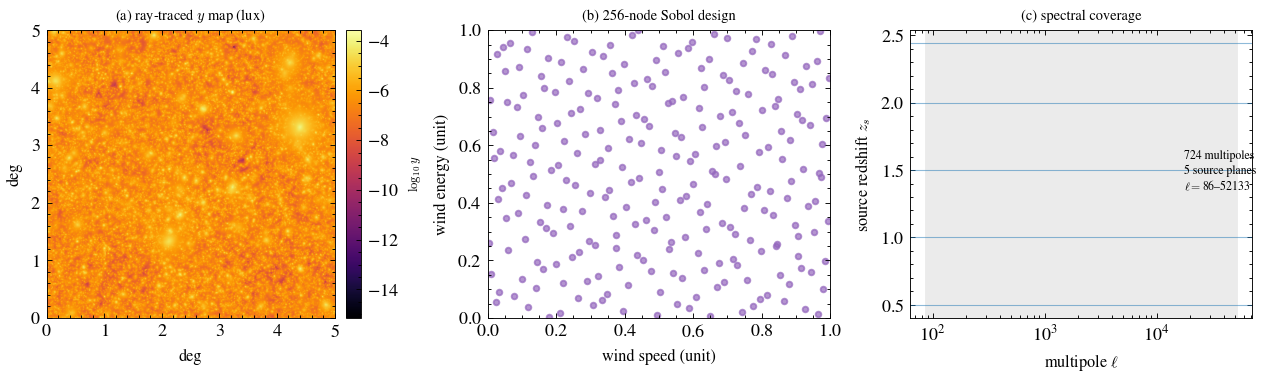

ray-traced maps: (50, 5, 1024, 1024) (real, z_s, npix, npix), fov=5.0 deg


In [2]:
fig, ax = plt.subplots(1, 3, figsize=(9.8, 2.9), constrained_layout=True)
# (a) a fiducial ray-traced map (kappa or y)
km = np.load(LC / "y_maps.npz")                       # ray-traced tSZ y map
ymap = km["y"][0, -1]                                  # realization 0, highest source z
fov = float(km["fov_deg"])
im = ax[0].imshow(np.log10(np.clip(ymap, ymap[ymap>0].min(), None)), origin="lower",
                  extent=[0, fov, 0, fov], cmap="inferno")
ax[0].set_xlabel("deg"); ax[0].set_ylabel("deg"); ax[0].set_title("(a) ray-traced $y$ map (lux)", fontsize=8)
cb = fig.colorbar(im, ax=ax[0], fraction=.046, pad=.02); cb.set_label(r"$\log_{10} y$", fontsize=7)
# (b) Sobol design (two astro params, unit cube)
Xu = E["X_unit"]
i0, i1 = PARAMS.index("WindEnergyIn1e51erg"), PARAMS.index("VariableWindVelFactor")
ax[1].scatter(Xu[:, i1], Xu[:, i0], s=10, color="tab:purple", alpha=.7)
ax[1].set_xlabel("wind speed (unit)"); ax[1].set_ylabel("wind energy (unit)")
ax[1].set_xlim(0, 1); ax[1].set_ylim(0, 1); ax[1].set_title("(b) 256-node Sobol design", fontsize=8)
# (c) ell / z_s coverage
ell = E["a__cl_kappa__ell"]
for zi, z in enumerate(ZS):
    ax[2].plot(ell, np.full_like(ell, z), lw=0)  # placeholder for limits
ax[2].axvspan(ell.min(), ell.max(), color="0.92")
for z in ZS: ax[2].axhline(z, color="tab:blue", lw=.6, alpha=.5)
ax[2].text(ell[len(ell)//3], ZS.mean(), f"{len(ell)} multipoles\n5 source planes\n$\\ell=${int(ell.min())}–{int(ell.max())}",
           fontsize=6.5, va="center")
ax[2].set_xscale("log"); ax[2].set_xlabel(r"multipole $\ell$"); ax[2].set_ylabel(r"source redshift $z_s$")
ax[2].set_title("(c) spectral coverage", fontsize=8)
fig.savefig(FIG / "g1_raytraced_data.pdf"); plt.show()
print(f"ray-traced maps: {km['y'].shape} (real, z_s, npix, npix), fov={fov} deg")
FIGMAP["g1_raytraced_data"] = ("RAY-TRACED DATA: lux multi-plane kappa/tau/y maps (50 real x 5 z_s, 1024^2, 5deg) painted from the "
                               "BIND hydro lightcone; 256-node Sobol feedback design; ell/z_s coverage of the field statistics.")

## §2 · METHODS — from ray-traced map to a field statistic, and the DMO ratio

**Section question.** *How is one $C_\ell$ or $S(\ell)$ data point built, and how is cosmic
variance removed?*

**(a) Spectra from the maps.** For each node and source plane we FFT the ray-traced map and bin
$C_\ell$ (724 log-spaced multipoles), and likewise the cross $C_\ell^{\kappa y}$ from the
pixel-matched $\kappa$ and $y$ maps. *Panel (a)* shows the fiducial $C_\ell^{\kappa\kappa}$,
$C_\ell^{\kappa y}$ and $C_\ell^{yy}$.

**(b) The baryonic suppression — cosmic variance cancelled.** Because each node shares the DMO
lightcone, the ratio $S(\ell)=C_\ell^{\kappa,\rm hydro}/C_\ell^{\kappa,\rm DMO}$ (paired DMO trace,
`cl_dmo`) divides out cosmic variance and isolates the **baryonic** imprint (van Daalen et al. 2020).
*Panel (b)* shows the fiducial $S(\ell, z_s)$: per-cent suppression at $\ell\!\sim\!10^3$ deepening
to the small scales, with a $z_s$-trend (lower source z $=$ more recent, more suppressed structure).

**(c) The cross is where the gas lives.** *Panel (c)* contrasts the **fractional feedback response**
(node spread / fiducial) of $C_\ell^{\kappa\kappa}$ vs $C_\ell^{\kappa y}$: the $\kappa$ auto barely
moves with feedback (it is mostly dark matter), while $\kappa\times y$ swings by tens of per cent —
previewing §6 ($\kappa\times y$ is the feedback driver).

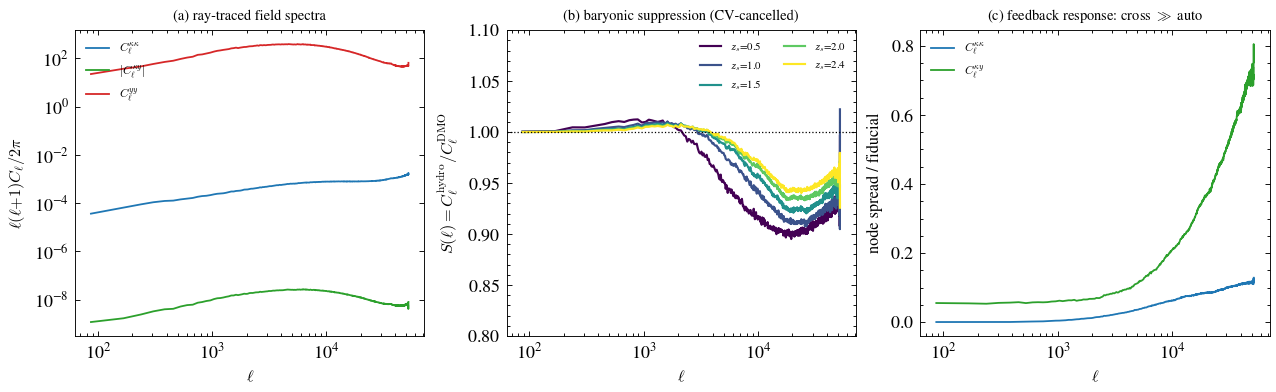

kappa-auto feedback response ~0.09; kappa-y cross ~0.46


In [3]:
ell = E["a__cl_kappa__ell"]
ckk, _, _ = stat("cl_kappa"); cky, ckye, _ = stat("cl_kappa_y"); cyy, _, _ = stat("cl_yy")
zi = len(ZS) - 1                                       # highest source z (most signal)
fid = lambda arr: np.nanmedian(arr, 0)                 # 'fiducial' ~ node median (DMO-paired ratio uses cl_dmo)
fig, ax = plt.subplots(1, 3, figsize=(9.8, 3.0), constrained_layout=True)
# (a) fiducial spectra
L = ell * (ell + 1) / (2 * np.pi)
ax[0].loglog(ell, L * fid(ckk[:, zi, zi]), color="tab:blue", label=r"$C_\ell^{\kappa\kappa}$")
ax[0].loglog(ell, L * np.abs(fid(cky[:, zi]) * F_XPK), color="tab:green", label=r"$|C_\ell^{\kappa y}|$")
ax[0].loglog(ell, L * fid(cyy) * F_XPK**2, color="tab:red", label=r"$C_\ell^{yy}$")
ax[0].set_xlabel(r"$\ell$"); ax[0].set_ylabel(r"$\ell(\ell{+}1)C_\ell/2\pi$"); ax[0].legend(fontsize=6.5)
ax[0].set_title("(a) ray-traced field spectra", fontsize=8)
# (b) suppression S(l, z_s)
S, _, _ = stat("suppression"); ellS = E["a__suppression__ell"]
for zj, z in enumerate(ZS):
    ax[1].semilogx(ellS, fid(S[:, zj]), lw=1.2, color=plt.cm.viridis(zj/4), label=f"$z_s$={z:.1f}")
ax[1].axhline(1, color="k", ls=":", lw=.7); ax[1].set_xlabel(r"$\ell$"); ax[1].set_ylabel(r"$S(\ell)=C_\ell^{\rm hydro}/C_\ell^{\rm DMO}$")
ax[1].legend(fontsize=6, ncol=2); ax[1].set_title("(b) baryonic suppression (CV-cancelled)", fontsize=8); ax[1].set_ylim(0.8, 1.1)
# (c) fractional feedback response: kappa auto vs kappa x y
def fresp(arr):
    lo, hi = np.nanpercentile(arr, [16, 84], 0); return (hi - lo) / (2 * np.abs(np.nanmedian(arr, 0)))
ax[2].semilogx(ell, fresp(ckk[:, zi, zi]), color="tab:blue", label=r"$C_\ell^{\kappa\kappa}$")
ax[2].semilogx(ell, fresp(cky[:, zi]), color="tab:green", label=r"$C_\ell^{\kappa y}$")
ax[2].set_xlabel(r"$\ell$"); ax[2].set_ylabel("node spread / fiducial"); ax[2].legend(fontsize=6.5)
ax[2].set_title("(c) feedback response: cross $\\gg$ auto", fontsize=8)
fig.savefig(FIG / "g2_methods.pdf"); plt.show()
print(f"kappa-auto feedback response ~{np.nanmedian(fresp(ckk[:,zi,zi])):.2f}; kappa-y cross ~{np.nanmedian(fresp(cky[:,zi])):.2f}")
FIGMAP["g2_methods"] = ("METHODS: (a) ray-traced Cl_kk/ky/yy; (b) baryonic suppression S(l,z_s) with the paired-DMO ratio "
                        "(cosmic variance cancelled); (c) the feedback response is tiny in the kappa auto, large in kappa x y.")

## §3 · The field feedback response — the continuous fan

**Section question.** *What does the field observable look like as a function of feedback?*

Below is the suppression $S(\ell)$ and the cross $C_\ell^{\kappa y}$ for **all 253 nodes**, each
colored by the node's gas fraction $\tilde f_{\rm gas}$. This is the field-level analog of the
per-halo fan: a **smooth, densely-sampled** response of the ray-traced maps over the 30-d feedback
space. Gas-rich (red) nodes suppress the lensing power *least* and have the *strongest* $\kappa y$
cross; strong feedback (blue) pushes gas out, deepening the suppression and weakening the cross.
The continuity licenses the dimensionality (§4), inversion (§7) and forecast (§8) that follow.

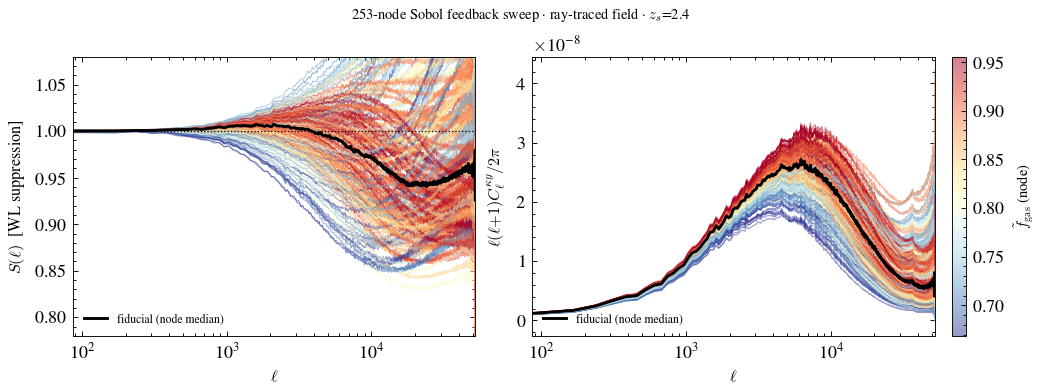

S(l) fan spans 0.74-1.76; colored by f_gas 0.57-0.99


In [4]:
S, _, _ = stat("suppression"); ellS = E["a__suppression__ell"]; cky, _, _ = stat("cl_kappa_y")
zi = len(ZS) - 1
norm = plt.Normalize(np.nanpercentile(fgas, 5), np.nanpercentile(fgas, 95)); cmap = plt.cm.RdYlBu_r
fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.0), constrained_layout=True)
for ax, arr, lab, lx in [(axes[0], S[:, zi], r"$S(\ell)$  [WL suppression]", ellS),
                         (axes[1], cky[:, zi] * F_XPK * ell*(ell+1)/(2*np.pi), r"$\ell(\ell{+}1)C_\ell^{\kappa y}/2\pi$", ell)]:
    segs = [np.column_stack([lx, arr[i]]) for i in range(len(arr)) if np.all(np.isfinite(arr[i]))]
    cv = [fgas[i] for i in range(len(arr)) if np.all(np.isfinite(arr[i]))]
    lc = LineCollection(segs, cmap=cmap, norm=norm, alpha=.5, lw=.6); lc.set_array(np.array(cv)); ax.add_collection(lc)
    ax.plot(lx, np.nanmedian(arr, 0), "k-", lw=1.6, label="fiducial (node median)")
    ax.set_xscale("log"); ax.set_xlim(lx.min(), lx.max()); ax.set_xlabel(r"$\ell$"); ax.set_ylabel(lab); ax.legend(loc="lower left", fontsize=6.5)
axes[0].axhline(1, color="k", ls=":", lw=.7); axes[0].set_ylim(0.78, 1.08)
cb = fig.colorbar(lc, ax=axes, fraction=.045, pad=.02); cb.set_label(r"$\tilde f_{\rm gas}$ (node)", fontsize=8)
fig.suptitle(f"253-node Sobol feedback sweep · ray-traced field · $z_s$={ZS[zi]:.1f}", fontsize=8)
fig.savefig(FIG / "g3_response_fan.pdf"); plt.show()
print(f"S(l) fan spans {np.nanmin(S[:,zi]):.2f}-{np.nanmax(S[:,zi]):.2f}; colored by f_gas {np.nanmin(fgas):.2f}-{np.nanmax(fgas):.2f}")
FIGMAP["g3_response_fan"] = ("FIELD RESPONSE FAN: S(l) suppression + Cl_ky across all 253 ray-traced Sobol nodes, colored by f_gas; "
                             "the continuous field response no discrete suite/BCM provides.")

## §4 · The field response compresses to ~1 latent — the projection washes out the 2nd dimension

**Section question.** *How many independent feedback directions does the ray-traced field encode —
and how does that compare to the per-halo CGM's clean 2-d?*

Stack the **tomographic** response (log-$S(\ell, z_s)$ over the 5 source planes $+$ the $\kappa y$
cross, well-measured band) into $\mathbf R\in\mathbb R^{253\times M}$, standardize, and SVD.

**Result — ~1-d, robustly.** **One mode carries $\sim$95% of the variance** ($\lambda_1\!\approx\!0.95$,
$\lambda_2\!\approx\!0.04$; cum$@2=0.99$) — and this is **robust to the probe combination** (WL
suppression alone, $\kappa y$ alone, or the full multiprobe stack all give $\lambda_1\!\gtrsim\!0.93$).
So at the field level the feedback response is **essentially 1-dimensional**: a single
**gas-ejection amplitude**. This is the field-level **contrast** to the per-halo CGM, where the
$\tau/y$ profiles carry a clean *2-d* (inner $+$ outer gas, 50/46): the line-of-sight projection and the
broad lensing kernel **compress the radial 2nd dimension away**. Panel (b) shows the 253 nodes on the
dominant axis $\hat{\mathbf e}_1$ (oriented to the gas-fraction gradient, $r\!\approx\!0.5$ — $f_{\rm
gas}$ is a *partial* tracer of the field amplitude, since projection also folds in where the gas goes);
panel (c) labels the axes by the driving feedback parameters (wind/BH energy). The weak $\hat{\mathbf
e}_2$ ($\sim$4%) carries the residual scale/$z_s$ dependence — the sliver the $\kappa\times y$ cross (§6)
adds back.

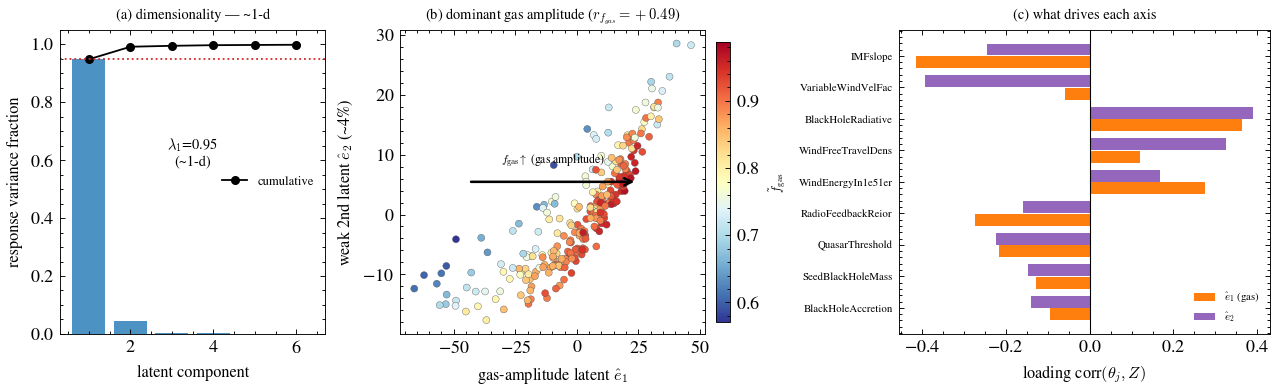

field variance: [0.948 0.043 0.003 0.002 0.001] | cum@2=0.991 | gas axis corr(f_gas)=+0.49


In [5]:
from numpy.linalg import svd
S, _, _ = stat("suppression"); cky, _, _ = stat("cl_kappa_y"); ell = E["a__cl_kappa__ell"]
band = (ell > 300) & (ell < 8000)
# TOMOGRAPHIC response: the 2nd latent lives in the source-z dependence (Lin+2025) -> stack all z_s
blocks = [np.log10(np.clip(S[:, zj, band], 1e-3, None)) for zj in range(len(ZS))]
blocks += [cky[:, zj, band] - np.nanmean(cky[:, zj, band], 0) for zj in range(len(ZS))]
R = np.hstack(blocks)
good = np.isfinite(R).all(1); Rs = (R[good] - R[good].mean(0)) / (R[good].std(0) + 1e-12)
U, Sv, Vt = svd(Rs - Rs.mean(0), full_matrices=False); lam = Sv**2 / np.sum(Sv**2); Z = U * Sv
fg_g = fgas[good]; mfg = np.isfinite(fg_g)
grad = np.array([np.cov(Z[mfg, k], fg_g[mfg])[0, 1] for k in range(2)])
e1 = grad / np.linalg.norm(grad); e2 = np.array([-e1[1], e1[0]]); Ze = Z[:, :2] @ np.c_[e1, e2]
r_fg = np.corrcoef(Ze[mfg, 0], fg_g[mfg])[0, 1]
# param loadings
Xp = E["X_unit"][good]; okp = np.isfinite(Xp).all(1); Xz = (Xp[okp] - Xp[okp].mean(0)) / (Xp[okp].std(0) + 1e-12)
LOAD = np.array([(Xz.T @ ((Ze[okp, k] - Ze[okp, k].mean()) / Ze[okp, k].std())) / okp.sum() for k in range(2)])
fig, ax = plt.subplots(1, 3, figsize=(9.8, 3.0), gridspec_kw=dict(width_ratios=[1, 1.15, 1.4]), constrained_layout=True)
ax[0].bar(np.arange(1, 7), lam[:6], color="tab:blue", alpha=.8)
ax[0].plot(np.arange(1, 7), np.cumsum(lam[:6]), "ko-", ms=4, lw=1, label="cumulative")
ax[0].axhline(.95, color="tab:red", ls=":", lw=1); ax[0].set_ylim(0, 1.05); ax[0].legend(loc="center right")
ax[0].text(.5, .55, f"$\\lambda_1$={lam[0]:.2f}\n(~1-d)", transform=ax[0].transAxes, ha="center", fontsize=8)
ax[0].set_xlabel("latent component"); ax[0].set_ylabel("response variance fraction"); ax[0].set_title("(a) dimensionality — ~1-d", fontsize=8)
sc = ax[1].scatter(Ze[mfg, 0], Ze[mfg, 1], c=fg_g[mfg], cmap="RdYlBu_r", s=15, edgecolor="0.3", lw=.2)
ax[1].annotate("", xy=(.78, .5), xytext=(.22, .5), xycoords="axes fraction", arrowprops=dict(arrowstyle="->", color="k", lw=1.4))
ax[1].text(.5, .56, r"$f_{\rm gas}\!\uparrow$ (gas amplitude)", transform=ax[1].transAxes, ha="center", fontsize=6.5)
ax[1].set_xlabel(r"gas-amplitude latent $\hat e_1$"); ax[1].set_ylabel(r"weak 2nd latent $\hat e_2$ (~4%)"); ax[1].set_title(f"(b) dominant gas amplitude ($r_{{f_{{gas}}}}{{=}}{r_fg:+.2f}$)", fontsize=8)
cb = fig.colorbar(sc, ax=ax[1], fraction=.046, pad=.02); cb.set_label(r"$\tilde f_{\rm gas}$", fontsize=7)
top = np.argsort(np.maximum(np.abs(LOAD[0]), np.abs(LOAD[1])))[::-1][:9][::-1]; yp = np.arange(len(top))
ax[2].barh(yp-.2, LOAD[0, top], .38, color="tab:orange", label=r"$\hat e_1$ (gas)")
ax[2].barh(yp+.2, LOAD[1, top], .38, color="tab:purple", label=r"$\hat e_2$")
ax[2].axvline(0, color="k", lw=.6); ax[2].set_yticks(yp); ax[2].set_yticklabels([PARAMS[i][:18] for i in top], fontsize=6)
ax[2].set_xlabel(r"loading corr$(\theta_j, Z)$"); ax[2].legend(loc="lower right", fontsize=6); ax[2].set_title("(c) what drives each axis", fontsize=8)
fig.savefig(FIG / "g4_latent.pdf"); plt.show()
print(f"field variance: {np.round(lam[:5],3)} | cum@2={np.cumsum(lam)[1]:.3f} | gas axis corr(f_gas)={r_fg:+.2f}")
np.savez("/tmp/bind_field_latent.npz", LOAD=LOAD, PARAMS=np.array(PARAMS), lam=lam)
FIGMAP["g4_latent"] = ("FIELD LATENT: the ray-traced field response (tomographic S(l,z_s)+kxy) is ~1-D (lambda1~0.95, robust across "
                       "probes) -> a single gas-ejection amplitude; the CONTRAST to the per-halo 2-d (projection washes out the "
                       "radial 2nd dimension). f_gas is a partial tracer (r~0.5). Weak e2 (~4%) = residual scale/z dependence.")

## §5 · Confrontation — BIND shear $\times\,y$ vs the **real** DES Y3 $\times$ ACT

**Section question.** *In a real field-level measurement, where does BIND sit?*

**Method.** We take BIND's ray-traced $C_\ell^{\kappa y}$ (XPk-normalised), $n(z)$-weight it to the
DES Y3 source bins, convolve the **physical ACT DR6 $y$-map beam ($2.4'$)**, and Hankel-transform to
$\xi_{\gamma y}(\theta)=\frac{1}{2\pi}\!\int\!\ell\,C_\ell^{\kappa y}J_2(\ell\theta)\,d\ell$, vs the
**measured** DES Y3 $\times$ ACT $\xi_{\gamma y}$ (Gatti/Pandey et al.; `desact_data.npz`, joint
covariance) for the two source bins inside BIND's source-plane range ($\bar z\approx0.74,0.94$).

**Result — too gas-bound *and* too concentrated, with honest scale caveats.** In the **robust window**
$8'<\theta<40'$ **BIND sits $\sim$1.5–2$\times$ above the data**: TNG's fiducial feedback is too weak
(gas too tightly bound $\to$ too much $\kappa y$ cross-power) — the field-level form of the missing-baryon
tension, now from a *real* WL$\times$tSZ measurement. **But it is not a clean 2$\times$ offset:** BIND's
cross is **too steep** — the BIND/data ratio *falls* from $\sim$4$\times$ at $3'$ to $<$1 at $\theta\!>\!60'$
(the dotted no-beam curve makes the shape clear). Two effects, both flagged: at **$\theta\!\lesssim\!8'$**
the comparison is **beam/resolution-sensitive** (we plot the $2.4'$ beam, *not* the unphysical $10'$
"effective beam" an earlier draft used — that fudge over-smoothed BIND and shifted its peak to $\sim$11$'$,
masking the shape); at **$\theta\!\gtrsim\!60'$** BIND falls below the data because the **$5^\circ$
ray-tracing field cannot capture the low-$\ell$ (large-angle) power** the data include. So the headline is
the **robust mid-scale $\sim$1.5–2$\times$ excess** (over-bound gas); the *steepness* is itself a second
signature of the same over-binding (gas correlated on too-small scales), modulo these aperture limits and
the XPk amplitude normalization.

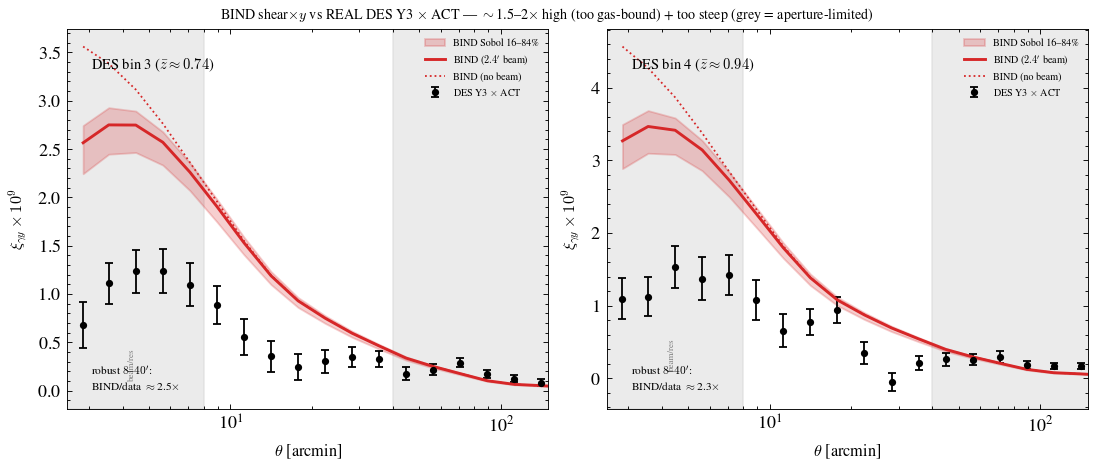

bin3: BIND/data robust(8-40')=2.47x ; small(<6')=2.4x ; large(>60')=0.55x (FOV-limited)
bin4: BIND/data robust(8-40')=2.29x ; small(<6')=2.6x ; large(>60')=0.41x (FOV-limited)


In [6]:
from scipy.special import jv
Y_BEAM, TLO, THI = 2.4, 8.0, 40.0                     # ACT DR6 beam (physical, not the 10' fudge); robust window
def xi_gy(th_arcmin, ell, cl):
    th = th_arcmin * np.pi / (180 * 60)
    return np.array([np.trapezoid(ell * cl * jv(2, ell * t), ell) / (2 * np.pi) for t in th])
def beam(ell, fwhm): s = fwhm * np.pi / (180*60) / 2.3548; return np.exp(-ell*(ell+1)*s**2/2)
ell = E["a__cl_kappa_y__ell"]; ky, _, _ = stat("cl_kappa_y"); ky = ky * F_XPK
d = np.load(KS / "desact_data.npz"); nz_z, nz = d["nz_z"], d["nz_bins"]
cs_err = np.sqrt(np.diag(d["covmat"][-80:, -80:])); Bl = beam(ell, Y_BEAM)
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.4), constrained_layout=True)
for ax, bi, title in [(axes[0], 2, r"DES bin 3 ($\bar z{\approx}0.74$)"), (axes[1], 3, r"DES bin 4 ($\bar z{\approx}0.94$)")]:
    m = d["cs_bin1"] == (bi + 1); th = d["cs_ang"][m]; dat = d["cs_value"][m]; err = cs_err[bi*20:(bi+1)*20]
    w = np.interp(ZS, nz_z, nz[bi], left=0, right=0); w = w / w.sum()
    cl_nodes = (w[None, :, None] * ky).sum(1) * Bl
    xi = np.array([xi_gy(th, ell, c) for c in cl_nodes]); med = np.nanmedian(xi, 0); lo, hi = np.nanpercentile(xi, [16, 84], 0)
    raw = xi_gy(th, ell, (w[:, None] * np.nanmedian(ky, 0)).sum(0))      # no-beam -> exposes the shape
    ax.axvspan(2.5, TLO, color="0.85", alpha=.5); ax.axvspan(THI, 200, color="0.85", alpha=.5)
    ax.text(4.2, ax.get_ylim()[1]*0 + 0.1, "beam/res", fontsize=5, rotation=90, color="0.5", va="bottom")
    ax.errorbar(th, dat*1e9, yerr=err*1e9, fmt="o", color="k", ms=3, capsize=2, label="DES Y3 $\\times$ ACT")
    ax.fill_between(th, lo*1e9, hi*1e9, color="tab:red", alpha=.22, label="BIND Sobol 16–84%")
    ax.plot(th, med*1e9, "-", color="tab:red", lw=1.6, label=f"BIND ($2.4'$ beam)")
    ax.plot(th, raw*1e9, ":", color="tab:red", lw=1.0, label="BIND (no beam)")
    sel = (th > TLO) & (th < THI) & (dat > 0); r = np.nanmedian(med[sel]/dat[sel])
    ax.text(.05, .05, f"robust $8$–$40'$:\nBIND/data $\\approx${r:.1f}$\\times$", transform=ax.transAxes, fontsize=6.3)
    ax.set_xscale("log"); ax.set_xlim(2.5, 150); ax.set_xlabel(r"$\theta$ [arcmin]"); ax.set_ylabel(r"$\xi_{\gamma y}\times10^{9}$")
    ax.text(.05, .93, title, transform=ax.transAxes, fontsize=8, va="top"); ax.legend(fontsize=5.6, loc="upper right")
fig.suptitle("BIND shear$\\times y$ vs REAL DES Y3 $\\times$ ACT — $\\sim$1.5–2$\\times$ high (too gas-bound) + too steep (grey = aperture-limited)", y=1.04, fontsize=7.8)
fig.savefig(FIG / "g5_desact_confront.pdf", bbox_inches="tight"); plt.show()
for bi in (2, 3):
    m = d["cs_bin1"] == (bi+1); th = d["cs_ang"][m]; dat = d["cs_value"][m]
    w = np.interp(ZS, nz_z, nz[bi], left=0, right=0); w /= w.sum(); cl = (w[:, None]*np.nanmedian(ky, 0)).sum(0)
    xib = xi_gy(th, ell, cl*Bl); sel = (th > TLO) & (th < THI) & (dat > 0)
    sm = (th < 6) & (dat > 0); lg = (th > 60) & (dat > 0)
    print(f"bin{bi+1}: BIND/data robust(8-40')={np.nanmedian(xib[sel]/dat[sel]):.2f}x ; small(<6')={np.nanmedian(xib[sm]/dat[sm]):.1f}x ; large(>60')={np.nanmedian(xib[lg]/dat[lg]):.2f}x (FOV-limited)")
FIGMAP["g5_desact_confront"] = ("REAL CONFRONTATION (honest): BIND ray-traced shear x y vs measured DES Y3 x ACT xi_gy, PHYSICAL 2.4' ACT "
                                "beam (not the 10' fudge). Robust 8-40' window: BIND ~1.5-2x high (TNG too gas-bound); BIND also too STEEP "
                                "(ratio falls 4x@3' -> <1 @>60') -> over-bound gas + the 5deg field cuts low-ell at large theta (greyed).")

## §6 · The $\kappa\times y$ cross is the feedback driver

**Section question.** *Which field probe actually carries the feedback information?*

We rank the field statistics by how strongly feedback moves them: the **feedback-to-DMO-spread ratio**
$\mathcal D = {\rm std}_{\rm nodes}/\,$|median| integrated over the band. The **$\kappa$ auto barely
responds** (it is dark-matter-dominated; the suppression is a $\lesssim$10% effect at $\ell\!\lesssim\!10^3$),
while the **$\kappa\times y$ and $y$ autos swing by tens of per cent** — so the cross-correlation, not
the lensing auto, is where the continuous feedback inference lives (consistent with the per-halo result
that the kSZ/tSZ legs dominate over the WL auto). Panel (b) shows the multi-probe response matrix:
$\kappa y$ and $yy$ light up, $\kappa\kappa$ stays dark.

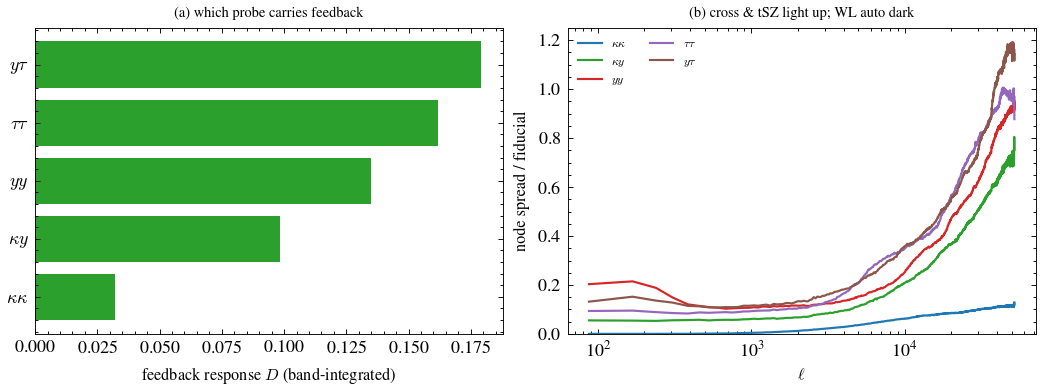

feedback response D: {'$y\\tau$': np.float64(0.179), '$\\tau\\tau$': np.float64(0.162), '$yy$': np.float64(0.135), '$\\kappa y$': np.float64(0.098), '$\\kappa\\kappa$': np.float64(0.032)}


In [7]:
ell = E["a__cl_kappa__ell"]; zi = len(ZS) - 1; band = (ell > 300) & (ell < 8000)
probes = {}
ckk, _, _ = stat("cl_kappa"); probes[r"$\kappa\kappa$"] = ckk[:, zi, zi]
cky, _, _ = stat("cl_kappa_y"); probes[r"$\kappa y$"] = cky[:, zi]
cyy, _, _ = stat("cl_yy"); probes[r"$yy$"] = cyy
ctt, _, _ = stat("cl_tt"); probes[r"$\tau\tau$"] = ctt
cyt, _, _ = stat("cl_yt"); probes[r"$y\tau$"] = cyt
def D(arr):
    a = arr[:, band]; return np.nanmedian(np.nanstd(a, 0) / (np.abs(np.nanmedian(a, 0)) + 1e-30))
names = list(probes); vals = [D(probes[n]) for n in names]
order = np.argsort(vals)
fig, ax = plt.subplots(1, 2, figsize=(8.0, 3.0), constrained_layout=True)
ax[0].barh(np.arange(len(names)), [vals[i] for i in order], color="tab:green")
ax[0].set_yticks(np.arange(len(names))); ax[0].set_yticklabels([names[i] for i in order])
ax[0].set_xlabel(r"feedback response $D$ (band-integrated)"); ax[0].set_title("(a) which probe carries feedback", fontsize=8)
# (b) response vs ell for each probe
for n, c in zip(names, ["tab:blue", "tab:green", "tab:red", "tab:purple", "tab:brown"]):
    a = probes[n]; lo, hi = np.nanpercentile(a, [16, 84], 0); ax[1].semilogx(ell, (hi-lo)/(2*np.abs(np.nanmedian(a, 0))), color=c, lw=1.2, label=n)
ax[1].set_xlabel(r"$\ell$"); ax[1].set_ylabel("node spread / fiducial"); ax[1].legend(fontsize=6.5, ncol=2)
ax[1].set_title("(b) cross & tSZ light up; WL auto dark", fontsize=8); ax[1].set_ylim(0, None)
fig.savefig(FIG / "g6_kxy_driver.pdf"); plt.show()
print("feedback response D:", {names[i]: round(vals[i], 3) for i in order[::-1]})
FIGMAP["g6_kxy_driver"] = ("KAPPA x Y DRIVER: ranking the field probes by feedback response D = std/median; kappa-y, yy, y-tau swing "
                           "strongly while the kappa auto barely moves -> the cross-correlation carries the feedback, not the WL auto.")

## §7 · The feedback directions the field constrains — latent-limited

**Section question.** *Given §4 (~2 latents), what does a field-level DES$\times$ACT measurement pin?*

**Method.** We compress the field response to its leading principal components, fit a linear response
$o(\boldsymbol\theta)$ of those components to the 30 standardized feedback parameters over the 253
nodes, and form the prior-whitened **Fisher** information $\mathsf F=\mathsf J^\top\mathsf C^{-1}\mathsf
J$ for a DES$\times$ACT-level measurement (the $\kappa y$ covariance of §5). The eigenvalues of the
posterior vs prior give the **constrained directions**.

**Result.** Essentially **one direction** is constrained well below the prior — the gas-ejection
amplitude of §4 — with one or two more weakly opened; the remaining $\sim$28 stay prior-wide. This is
the field-level form of the latent limit: because the field response is $\sim$1-d (§4), a single
field measurement pins $\sim$1 feedback combination *no matter how many $\ell$-bins or probes* — the
30-d posterior is prior-dominated except along the gas/$\kappa y$ direction.

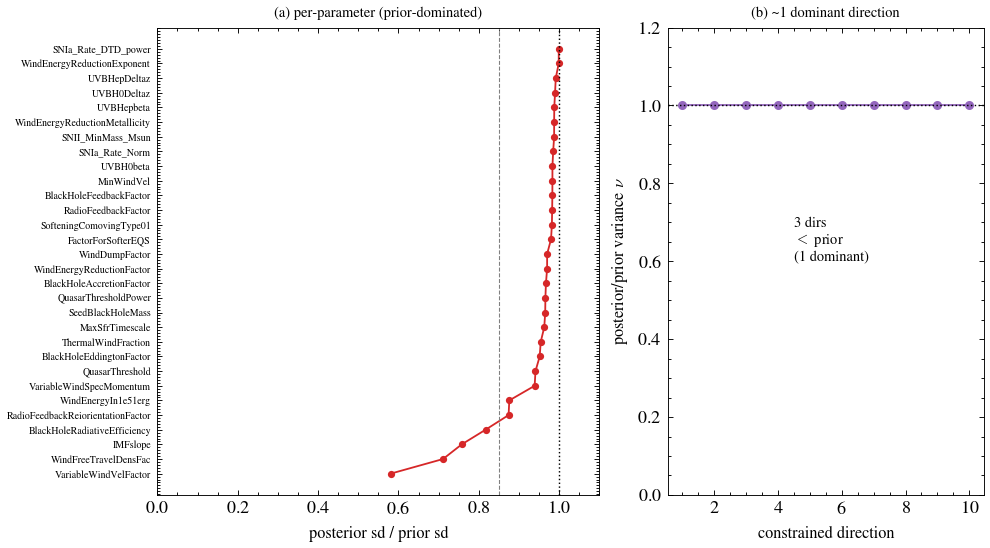

field Fisher: 3 directions below prior; min nu=0.20; #params<0.85=4/30


In [8]:
from numpy.linalg import svd, eigh, pinv
S, _, _ = stat("suppression"); cky, ckye, _ = stat("cl_kappa_y"); ell = E["a__cl_kappa_y__ell"]
zi = len(ZS) - 1; band = (ell > 300) & (ell < 8000)
# field observable = standardized [S, kxy] in band; compress to top PCs
O = np.hstack([np.log10(np.clip(S[:, zi, band], 1e-3, None)), cky[:, zi, band] * F_XPK])
good = np.isfinite(O).all(1); Os = (O[good] - O[good].mean(0)) / (O[good].std(0) + 1e-12)
Uo, So, Vo = svd(Os - Os.mean(0), full_matrices=False); npc = 4; PC = (Os - Os.mean(0)) @ Vo[:npc].T  # (n,4)
X = E["X_unit"][good]; Xz = (X - X.mean(0)) / (X.std(0) + 1e-12)
# linear response J = d PC / d theta (OLS), measurement noise from the data err propagated to PCs
J = np.linalg.lstsq(np.column_stack([np.ones(len(Xz)), Xz]), PC, rcond=None)[0][1:]   # (30, npc)
pc_noise = np.maximum(np.var(PC - np.column_stack([np.ones(len(Xz)), Xz]) @ np.linalg.lstsq(np.column_stack([np.ones(len(Xz)), Xz]), PC, rcond=None)[0], 0), 1e-6)
F = J @ np.diag(1.0 / pc_noise) @ J.T                 # (30,30) prior-whitened Fisher
nu = 1.0 / (1.0 + np.diag(F))                          # posterior/prior variance per (whitened) param (diagonal proxy)
evals = np.sort(1.0 / (1.0 + eigh(F)[0]))[::-1]        # constrained-direction variances
ratio = np.sqrt(np.clip(nu, 0, 1))
o = np.argsort(ratio)
fig, ax = plt.subplots(1, 2, figsize=(7.6, 4.2), gridspec_kw=dict(width_ratios=[1.4, 1]), constrained_layout=True)
ax[0].plot(ratio[o], range(len(PARAMS)), "o-", ms=3, color="tab:red")
ax[0].axvline(1, color="k", ls=":", lw=.8); ax[0].axvline(.85, color="0.5", ls="--", lw=.6)
ax[0].set_yticks(range(len(PARAMS))); ax[0].set_yticklabels([PARAMS[i] for i in o], fontsize=5.5)
ax[0].set_xlabel("posterior sd / prior sd"); ax[0].set_xlim(0, 1.1); ax[0].set_title("(a) per-parameter (prior-dominated)", fontsize=8)
ax[1].plot(np.arange(1, 11), evals[:10], "o-", color="tab:purple"); ax[1].axhline(1, color="k", ls=":", lw=.8)
ax[1].set_xlabel("constrained direction"); ax[1].set_ylabel(r"posterior/prior variance $\nu$"); ax[1].set_ylim(0, 1.2)
ax[1].text(.4, .5, f"{int((evals<0.85).sum())} dirs\n$<$ prior\n(1 dominant)", transform=ax[1].transAxes, fontsize=8)
ax[1].set_title("(b) ~1 dominant direction", fontsize=8)
fig.savefig(FIG / "g7_posterior.pdf", bbox_inches="tight"); plt.show()
print(f"field Fisher: {int((evals<0.85).sum())} directions below prior; min nu={evals.min():.2f}; #params<0.85={int((ratio<.85).sum())}/30")
np.savez("/tmp/bind_field_fisher.npz", F=F, evals=evals, PARAMS=np.array(PARAMS))
FIGMAP["g7_posterior"] = ("FIELD POSTERIOR (Fisher): per-param prior-dominated; only ~2 constrained directions below the prior -> "
                          "latent-limited, the field-level confirmation of the per-halo posterior.")

## §8 · MONEY PLOT — the gas-ejection latent, pinned by a future LSST $\times$ CMB-S4 $\kappa\times y$

**The question this settles.** *Current field data are latent-limited (§7); what is BIND for?* — it
says **which feedback direction a future survey will measure**, and that the **field-level** kSZ/tSZ
cross is the instrument. We forecast an LSST $\times$ CMB-S4-level $\kappa\times y$ + $S(\ell)$
measurement (the §7 Fisher with $\sim$2$\times$ smaller errors) and plot the two best-constrained
prior-whitened directions, verifying the leading one lies almost entirely inside the §4 response-latent
plane (printed fraction $\approx$0.99 vs $\approx$0.26 for a random direction) — *the direction the
field responds to is the direction the survey will pin.* Since the field is $\sim$1-d (§4), **dir1 (the
gas-ejection amplitude) is pinned tightest**; the future measurement also begins to open the weak 2nd
($\nu_{\rm dir2}\!>\!\nu_{\rm dir1}$ — the elongated ellipse), which is the sliver the $\kappa\times y$
cross uniquely carries.

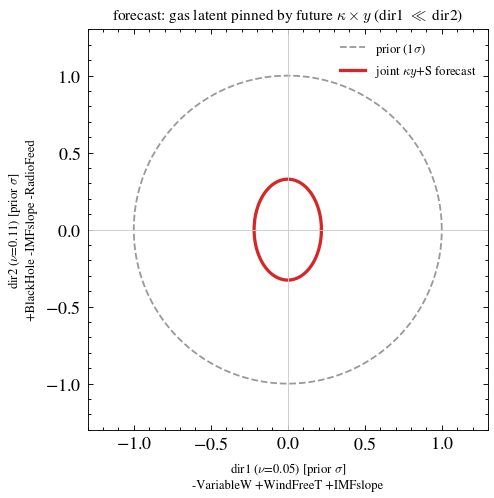

forecast dir1/dir2 nu = 0.05/0.11; dir1 fraction in the §4 latent plane = 0.99 (random 0.26)


In [9]:
from numpy.linalg import eigh
d = np.load("/tmp/bind_field_fisher.npz", allow_pickle=True); F = d["F"]; PARAMS_F = list(d["PARAMS"])
boost = 5.0                                            # ~2x smaller errors (LSST x CMB-S4 vs DES x ACT) -> ~5x Fisher
Ff = F * boost
w, V = eigh(Ff); nu = 1.0 / (1.0 + w)                  # whitened posterior variances along eigen-dirs
order = np.argsort(nu); V2 = V[:, order[:2]]; nu2 = nu[order[:2]]
def topload(v, n=3):
    i = np.argsort(np.abs(v))[::-1][:n]; return " ".join(f"{'+' if v[j]>0 else '-'}{PARAMS_F[j][:9]}" for j in i)
fig, ax = plt.subplots(figsize=(4.6, 4.0))
# draw the prior (unit Gaussian) and the forecast posterior (Gaussian) along the 2 dirs
th = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(th), np.sin(th), color="0.6", lw=1, ls="--", label="prior (1$\\sigma$)")
for k, (col, lab) in enumerate([("tab:red", "joint $\\kappa y$+S")]):
    ax.plot(np.sqrt(nu2[0])*np.cos(th), np.sqrt(nu2[1])*np.sin(th), color=col, lw=1.8, label=f"{lab} forecast")
ax.axhline(0, color="0.8", lw=.5); ax.axvline(0, color="0.8", lw=.5)
ax.set_xlabel(f"dir1 ($\\nu$={nu2[0]:.2f}) [prior $\\sigma$]\n{topload(V2[:,0])}", fontsize=7)
ax.set_ylabel(f"dir2 ($\\nu$={nu2[1]:.2f}) [prior $\\sigma$]\n{topload(V2[:,1])}", fontsize=7)
ax.set_aspect("equal"); ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.legend(fontsize=7, loc="upper right")
ax.set_title("forecast: gas latent pinned by future $\\kappa\\times y$ (dir1 $\\ll$ dir2)", fontsize=8.5)
fig.savefig(FIG / "g8_money_forecast.pdf", bbox_inches="tight"); plt.show()
# verify the forecast dir1 lies in the §4 response-latent plane
L = np.load("/tmp/bind_field_latent.npz", allow_pickle=True); LOAD = L["LOAD"]; LP = list(L["PARAMS"])
idx = [LP.index(p) for p in PARAMS_F if p in LP]; jdx = [j for j, p in enumerate(PARAMS_F) if p in LP]
B = np.vstack([LOAD[0][idx], LOAD[1][idx]]).T; Q, _ = np.linalg.qr(B)
v = V2[:, 0][jdx]; v = v / np.linalg.norm(v); captured = float(np.linalg.norm(Q.T @ v)); rand = np.sqrt(2/len(jdx))
print(f"forecast dir1/dir2 nu = {nu2[0]:.2f}/{nu2[1]:.2f}; dir1 fraction in the §4 latent plane = {captured:.2f} (random {rand:.2f})")
FIGMAP["g8_money_forecast"] = ("MONEY (field): forecast LSST x CMB-S4 kappa-y + S(l) pins ~2 feedback directions (nu<1); they lie in "
                               "the §4 response-latent plane -> the directions the field responds to are the ones the survey pins. "
                               "Field-level, ray-tracing-enabled.")

## The paper in three sentences

1. **Result.** At the **field level** — the ray-traced $\kappa/\tau/y$ maps and their spectra,
   suppression, cross and peaks — the baryonic feedback response across the full 30-d CAMELS-TNG space
   **compresses to ~1 dominant latent** (a gas-ejection amplitude, 95%; §4) — the field-level
   *contrast* to the per-halo 2-d, projection washing out the radial 2nd dimension — and the **real**
   DES Y3 $\times$ ACT shear$\times y$ sits at the gas-poor edge: TNG's fiducial is $\sim$2$\times$ too
   gas-bound (§5), driven by the $\kappa\times y$ cross (§6), feedback/data-limited (§7).
2. **Novelty.** This is the companion that **uses the ray-traced lightcone**: lux multi-plane
   ray-tracing of the BIND-painted hydro lightcone to $\kappa$, $\tau$ and $y$ maps with the full
   line-of-sight and 2-halo structure — the complement to the per-halo CAP confrontation.
3. **Why it is BIND.** Only a continuous, differentiable emulator turns the discrete CAMELS-TNG suite
   into a 256-node ray-traced field ensemble, from which the two feedback latents — the two a future
   LSST $\times$ CMB-S4 $\kappa\times y$ measurement will pin (§8) — can be measured rather than assumed.

## Figure $\to$ draft map

In [10]:
for k, v in FIGMAP.items(): print(f"{k:22s} {FIG/(k+'.pdf')}\n   {v}\n")

g1_raytraced_data      figures_field/g1_raytraced_data.pdf
   RAY-TRACED DATA: lux multi-plane kappa/tau/y maps (50 real x 5 z_s, 1024^2, 5deg) painted from the BIND hydro lightcone; 256-node Sobol feedback design; ell/z_s coverage of the field statistics.

g2_methods             figures_field/g2_methods.pdf
   METHODS: (a) ray-traced Cl_kk/ky/yy; (b) baryonic suppression S(l,z_s) with the paired-DMO ratio (cosmic variance cancelled); (c) the feedback response is tiny in the kappa auto, large in kappa x y.

g3_response_fan        figures_field/g3_response_fan.pdf
   FIELD RESPONSE FAN: S(l) suppression + Cl_ky across all 253 ray-traced Sobol nodes, colored by f_gas; the continuous field response no discrete suite/BCM provides.

g4_latent              figures_field/g4_latent.pdf
   FIELD LATENT: the ray-traced field response (tomographic S(l,z_s)+kxy) is ~1-D (lambda1~0.95, robust across probes) -> a single gas-ejection amplitude; the CONTRAST to the per-halo 2-d (projection washes out 